# Assignment 3 — Authorship Attribution

Predict the author (20 classes) of each fanfiction snippet.

In [1]:
from src.dataloader import load_all

splits = load_all()
for name, (texts, authors) in splits.items():
    print(f"{name}: {len(texts)} snippets, {len(set(authors))} authors")

train: 2138 snippets, 20 authors
dev: 268 snippets, 20 authors
test: 267 snippets, 20 authors


In [2]:
# NLTK data and the NRC emotion lexicon; only downloads what is missing
from src.features import download_resources

download_resources()

In [3]:
from src.features import extract_all
from src.model import Classifier

train_texts, train_y = splits["train"]
dev_texts, dev_y = splits["dev"]

train_X = extract_all(train_texts)
dev_X = extract_all(dev_texts)

model = Classifier().train(train_X, train_y)
pred = model.predict(dev_X)

F1 (micro): 0.937
Macro-F1  : 0.923


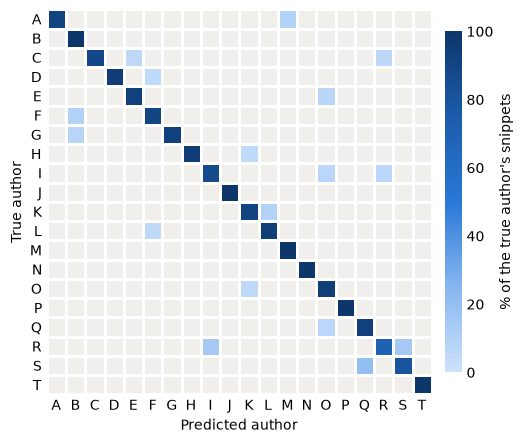

In [4]:
from src.evaluation import f1, macro_f1, confusion

print("F1 (micro):", round(f1(dev_y, pred), 3))
print("Macro-F1  :", round(macro_f1(dev_y, pred), 3))
ax = confusion(dev_y, pred)
ax.figure.savefig("outputs/confusion_dev.png", dpi=300, bbox_inches="tight")

## Classifier comparison

In [5]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

classifiers = {
    "linear SVM": LinearSVC(),
    "logistic regression": LogisticRegression(max_iter=5000),
    "random forest": RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1),
}

import pandas as pd

rows = []
for name, clf in classifiers.items():
    clf_pred = Classifier(clf).train(train_X, train_y).predict(dev_X)
    rows.append({"classifier": name, "micro_f1": f1(dev_y, clf_pred), "macro_f1": macro_f1(dev_y, clf_pred)})

comparison = pd.DataFrame(rows)
comparison.to_csv("outputs/classifier_comparison.csv", index=False)
comparison

,classifier,micro_f1,macro_f1
0,linear SVM,0.936567,0.923000
1,logistic regression,0.936567,0.926299
2,random forest,0.917910,0.890311


## Tuning C

C sets the regularization strength of both linear models (smaller C = stronger regularization). Each setting is trained on train and scored on dev; the best macro-F1 is kept.

In [6]:
import numpy as np
import pandas as pd

C_VALUES = np.logspace(-3, 2, 11)
candidates = {
    "linear SVM": lambda C: LinearSVC(C=C, max_iter=20000),
    "logistic regression": lambda C: LogisticRegression(C=C, max_iter=5000),
}

rows = []
for name, make in candidates.items():
    for C in C_VALUES:
        c_pred = Classifier(make(C)).train(train_X, train_y).predict(dev_X)
        rows.append({"classifier": name, "C": C,
                     "micro_f1": f1(dev_y, c_pred), "macro_f1": macro_f1(dev_y, c_pred)})

tuning = pd.DataFrame(rows)
tuning.to_csv("outputs/tuning.csv", index=False)

best = tuning.loc[tuning["macro_f1"].idxmax()]
best_name, best_C = best["classifier"], best["C"]

# the tuned model, used by the ablation and the test run below
best_clf = candidates[best_name](best_C)
best

classifier    linear SVM
C               0.031623
micro_f1        0.966418
macro_f1        0.953372
Name: 3, dtype: object

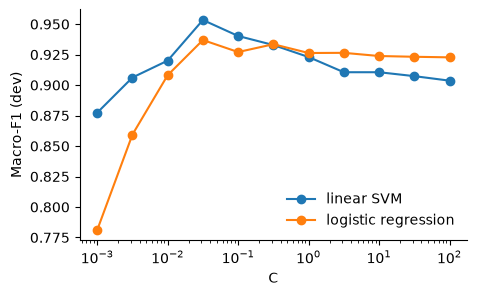

In [7]:
import matplotlib.pyplot as plt

ax = plt.subplots(figsize=(5, 3))[1]
for name, group in tuning.groupby("classifier"):
    ax.plot(group["C"], group["macro_f1"], marker="o", label=name)
ax.set_xscale("log")
ax.set_xlabel("C")
ax.set_ylabel("Macro-F1 (dev)")
ax.legend(frameon=False)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.figure.savefig("outputs/tuning_c.png", dpi=300, bbox_inches="tight")

## Ablation analysis

Leave one feature group out at a time and check how the score drops. A lower score means the group was more informative.

150 features in 7 groups


,group_left_out,micro_f1,macro_f1
0,all,0.966418,0.953372
1,character,0.929104,0.914979
2,punctuation,0.921642,0.908717
3,structure,0.947761,0.931594
4,lexical,0.947761,0.931546
5,syntactic,0.940299,0.927796
6,informal,0.902985,0.883405
7,semantic,0.944030,0.930333


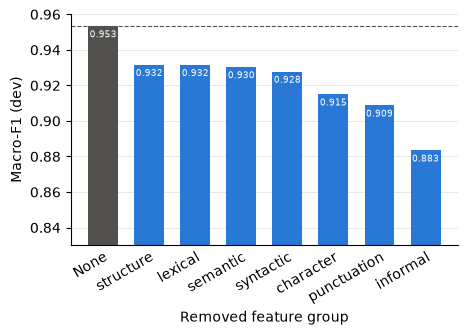

In [8]:
from src.features import FEATURE_NAMES, FEATURE_GROUPS
from src.ablation import ablate, plot_ablation

print(f"{len(FEATURE_NAMES)} features in {len(FEATURE_GROUPS)} groups")

scores = ablate(FEATURE_GROUPS, train_X, train_y, dev_X, dev_y, clf=best_clf)

ablation = pd.DataFrame(scores).T.rename_axis("group_left_out").reset_index()
ablation.to_csv("outputs/ablation.csv", index=False)
display(ablation)

ax = plot_ablation(scores)
ax.figure.savefig("outputs/ablation.png", dpi=300, bbox_inches="tight")